# 01: Ternary Weight Packing

Pack $\{-1, 0, +1\}$ weights into TL1 format for SIMD inference.

For models already trained with ternary weights (BitNet, Falcon-E), absmean scaling
detects and decodes them:

- $\gamma = \text{mean}(|W|)$ per tensor (or read from model's weight_scale)
- $W_t = \text{RoundClip}(W / \gamma,\ -1,\ 1)$
- Forward: $y = \gamma \cdot (W_t \cdot x)$ using additions only

For float models, must use PTQTP two-plane decomposition.

In [ ]:
import os
import sys

if "COLAB_GPU" in os.environ:
    os.system("pip install -q git+https://github.com/PritRaj1/smelt.git")
    os.system("pip install -q 'transformers>=4.51,<5'")
else:
    sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd())))

import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from smelt.matmul import TernaryLinear, pack_tl1, quantize_ternary, unpack_tl1

## Quantization of a single weight matrix

In [2]:
torch.manual_seed(42)
W = torch.randn(128, 256)
W_t, scale = quantize_ternary(W)

vals, counts = W_t.unique(return_counts=True)
total = W_t.numel()
print("value  count  fraction")
for v, c in zip(vals.tolist(), counts.tolist(), strict=True):
    print(f"  {v:+d}   {c:>5d}   {c / total:.1%}")

value  count  fraction
  -1   11258   34.4%
  +0   10169   31.0%
  +1   11341   34.6%


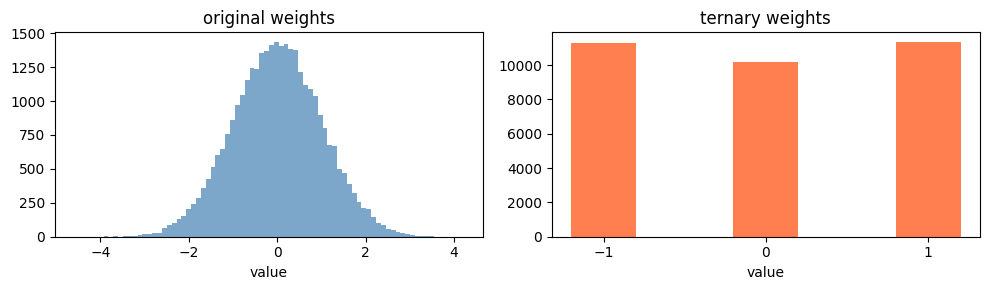

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

ax1.hist(W.flatten().numpy(), bins=80, color="steelblue", alpha=0.7)
ax1.set_title("original weights")
ax1.set_xlabel("value")

ax2.bar([-1, 0, 1], [counts[i].item() for i in range(3)], color="coral", width=0.4)
ax2.set_title("ternary weights")
ax2.set_xlabel("value")
ax2.set_xticks([-1, 0, 1])

plt.tight_layout()
plt.show()

## Reconstruction error

$W_{\text{approx}} \approx \gamma \cdot W_t$ ?

In [4]:
W_recon = scale * W_t.float()
err = (W - W_recon).abs()

print(f"mean abs error:  {err.mean():.4f}")
print(f"max  abs error:  {err.max():.4f}")
print(f"NMSE:            {((W - W_recon) ** 2).mean() / (W**2).mean():.4f}")

mean abs error:  0.3589
max  abs error:  3.7886
NMSE:            0.2624


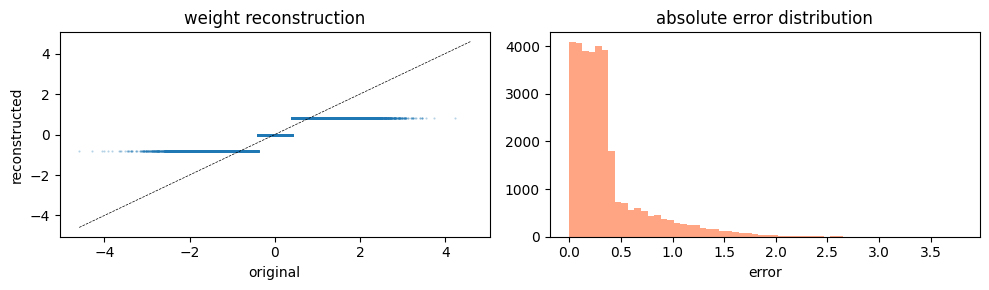

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

ax1.scatter(W.flatten().numpy(), W_recon.flatten().numpy(), s=0.3, alpha=0.3)
lim = max(W.abs().max().item(), W_recon.abs().max().item())
ax1.plot([-lim, lim], [-lim, lim], "k--", lw=0.5)
ax1.set_xlabel("original")
ax1.set_ylabel("reconstructed")
ax1.set_title("weight reconstruction")

ax2.hist(err.flatten().numpy(), bins=60, color="coral", alpha=0.7)
ax2.set_title("absolute error distribution")
ax2.set_xlabel("error")

plt.tight_layout()
plt.show()

## TL1 packing

Pack pairs of weights into 4-bit indices. Index = (w0+1)*3 + (w1+1), two per byte.
Transposed layout for SIMD: [k_pairs, n_cols] so vpshufb can process 64 columns at once.

Storage: 4 bits per weight vs 32 bits float. 8x compression (further 2x from the transposed layout reuse).

In [ ]:
packed, n_pairs, n_padded = pack_tl1(W_t)
W_roundtrip = unpack_tl1(packed, n_pairs, n_padded, 128, 256)

print(f"packed shape:  {packed.shape} (was {W_t.shape})")
print(f"bytes packed:  {packed.numel()}")
print(f"bytes float32: {W.numel() * 4}")
print(f"ratio:         {W.numel() * 4 / packed.numel():.0f}x")
print(f"roundtrip ok:  {(W_t == W_roundtrip).all().item()}")

## Forward pass comparison

Compare `nn.Linear` (float matmul) vs `TernaryLinear` (additions only).

In [7]:
torch.manual_seed(0)
linear = nn.Linear(256, 128, bias=False)
x = torch.randn(16, 256)

y_ref = linear(x)
y_t = TernaryLinear(linear)(x)

mse = ((y_ref - y_t) ** 2).mean()
nmse = mse / (y_ref**2).mean()

print(f"MSE:   {mse:.4f}")
print(f"NMSE:  {nmse:.4f}")

MSE:   0.0529
NMSE:  0.1527


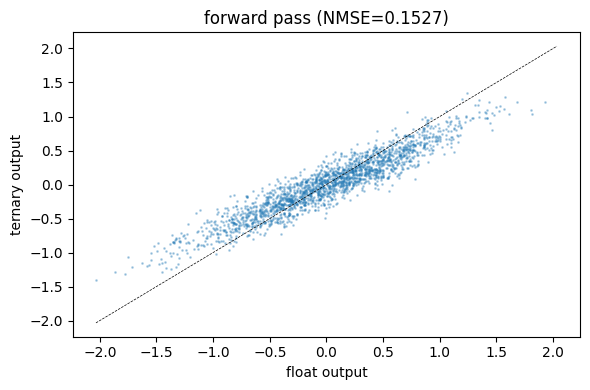

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(y_ref.detach().flatten().numpy(), y_t.detach().flatten().numpy(), s=1, alpha=0.3)
lim = max(y_ref.abs().max().item(), y_t.abs().max().item())
ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.5)
ax.set_xlabel("float output")
ax.set_ylabel("ternary output")
ax.set_title(f"forward pass (NMSE={nmse:.4f})")
plt.tight_layout()
plt.show()